In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 12.81it/s]


Numba compilation complete!
0.23.9


## 1. Load and Prepare Data

In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20251023"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Climbing = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarclimbing\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = ["fonts"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

In [4]:
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-Full.xlsx")

responder_filter = "Chrimson2"

if responder_filter == 'Chrimson2':
    responderrename = "CsChrimson"
    df = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)

if responder_filter == 'ACR':
    responderrename = "GtACR1"
    df = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)

In [10]:
df.columns

Index(['Fall number_ΔΔ_Climbing', 'Speed_Δg_Climbing',
       'Max height climbed_Δg_Climbing', 'Bout speed_Δg_Climbing',
       'Pause position_Δg_Climbing', 'Max velocity_Δg_Climbing',
       'Straightness Index_Δg_Climbing', 'Duration of bouts_Δg_Climbing',
       'Number of Bouts_Δg_Climbing', 'Log2 Bout Speed ratio_Hg_Climbing',
       'Log2 Speed ratio_Hg_Climbing', 'Bout number index_Hg_Climbing',
       'Bout duration ratio_Hg_Climbing', 'Max velocity_Hg_Climbing',
       'responder', 'genotypeandresponder', 'MBON', 'PI_Hg_OSAR',
       'Log2 Speed ratio_Hg_OSAR', 'Log2 Bout Speed ratio_Hg_OSAR',
       'Light Attraction Index_Hg_OSAR', 'Bout Number Index_Hg_OSAR',
       'Bout Duration ratio_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR',
       'Speed ratio_Hg_OSAR', 'Bout Speed ratio_Hg_OSAR'],
      dtype='object')

In [ ]:
# Identify metadata vs metric columns
metadata_cols = ['MBON', 'genotypeandresponder', 'responder']
metric_cols = [col for col in df.columns if col not in metadata_cols]
metric_data = df[metric_cols]

## 2. Calculate Metric Correlations

In [8]:
# Calculate correlation matrix using Spearman (robust to different effect sizes)
correlation_method = 'spearman'  # Change to 'pearson' if preferred
corr_matrix = metric_data.corr(method=correlation_method)

## 3. Hierarchical Clustering of Metrics

In [ ]:
# Convert correlation to distance (1 - |correlation|)
distance_matrix = 1 - np.abs(corr_matrix)
# High correlation (0.9) → Small distance (0.1) → Metrics are "close"
# Low correlation (0.1) → Large distance (0.9) → Metrics are "far apart"

# Convert to condensed distance matrix for scipy
distance_condensed = squareform(distance_matrix.values)

# Perform hierarchical clustering
linkage_method = 'ward'  # Can also try 'average', 'complete', 'single'
linkage_matrix = hierarchy.linkage(distance_condensed, method=linkage_method)

linkage_matrix

array([[8.00000000e+00, 1.10000000e+01, 1.86950147e-02, 2.00000000e+00],
       [2.00000000e+00, 4.00000000e+00, 2.63929619e-02, 2.00000000e+00],
       [3.00000000e+00, 9.00000000e+00, 5.38856305e-02, 2.00000000e+00],
       [1.00000000e+00, 1.00000000e+01, 1.03372434e-01, 2.00000000e+00],
       [5.00000000e+00, 1.30000000e+01, 1.05224550e-01, 2.00000000e+00],
       [7.00000000e+00, 1.20000000e+01, 1.48565664e-01, 2.00000000e+00],
       [1.60000000e+01, 2.20000000e+01, 2.18841642e-01, 2.00000000e+00],
       [1.50000000e+01, 2.10000000e+01, 2.51832845e-01, 2.00000000e+00],
       [6.00000000e+00, 2.80000000e+01, 4.09919743e-01, 3.00000000e+00],
       [1.70000000e+01, 1.80000000e+01, 4.39516129e-01, 2.00000000e+00],
       [1.90000000e+01, 3.20000000e+01, 5.46348843e-01, 3.00000000e+00],
       [1.40000000e+01, 3.00000000e+01, 5.50930559e-01, 3.00000000e+00],
       [0.00000000e+00, 2.70000000e+01, 6.36282177e-01, 3.00000000e+00],
       [2.40000000e+01, 2.60000000e+01, 7.28113696e

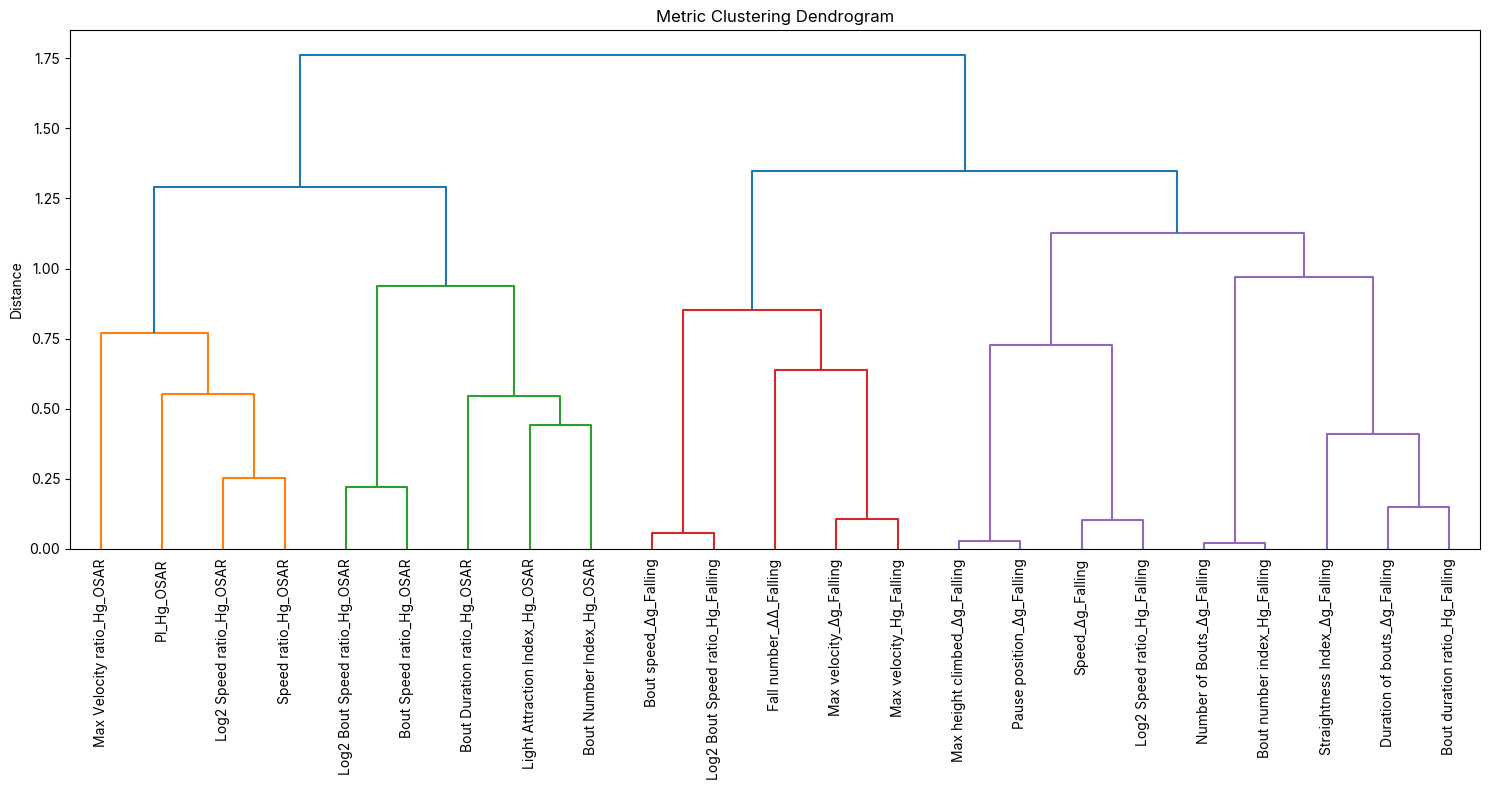

<Figure size 1200x1000 with 0 Axes>

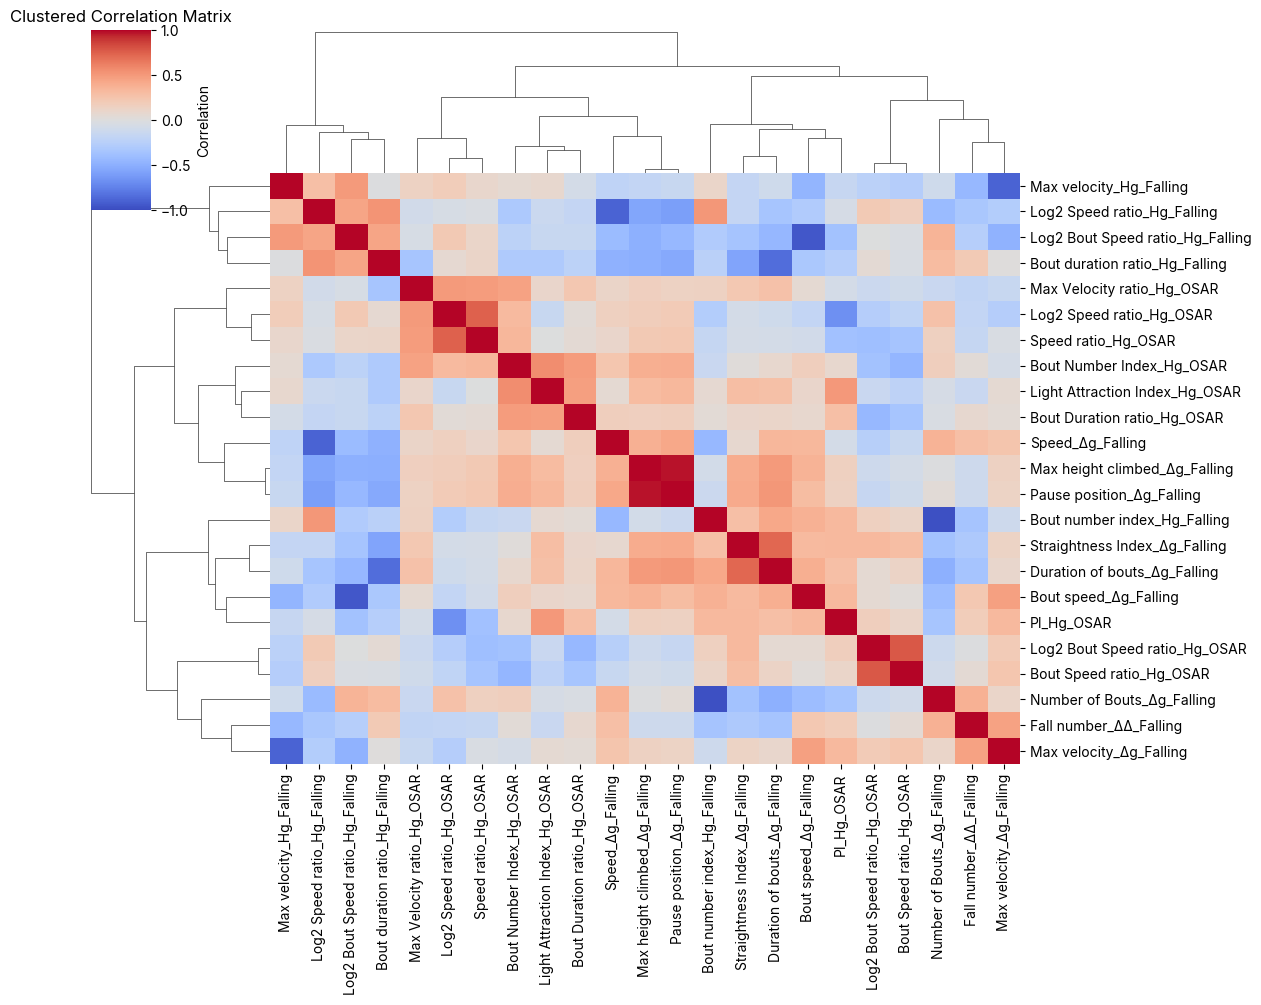


Cluster 1:
  - Log2 Speed ratio_Hg_OSAR
  - Speed ratio_Hg_OSAR

Cluster 2:
  - PI_Hg_OSAR

Cluster 3:
  - Max Velocity ratio_Hg_OSAR

Cluster 4:
  - Log2 Bout Speed ratio_Hg_OSAR
  - Bout Speed ratio_Hg_OSAR

Cluster 5:
  - Light Attraction Index_Hg_OSAR
  - Bout Number Index_Hg_OSAR

Cluster 6:
  - Bout Duration ratio_Hg_OSAR

Cluster 7:
  - Bout speed_Δg_Climbing
  - Log2 Bout Speed ratio_Hg_Climbing

Cluster 8:
  - Max velocity_Δg_Climbing
  - Max velocity_Hg_Climbing

Cluster 9:
  - Fall number_ΔΔ_Climbing

Cluster 10:
  - Max height climbed_Δg_Climbing
  - Pause position_Δg_Climbing

Cluster 11:
  - Speed_Δg_Climbing
  - Log2 Speed ratio_Hg_Climbing

Cluster 12:
  - Number of Bouts_Δg_Climbing
  - Bout number index_Hg_Climbing

Cluster 13:
  - Straightness Index_Δg_Climbing
  - Duration of bouts_Δg_Climbing
  - Bout duration ratio_Hg_Climbing

⚠️ Highly Correlated Metric Pairs (potential redundancies):
  Max height climbed_Δg_Climbing ↔ Pause position_Δg_Climbing: 0.974
  Straig

In [9]:
# Here's code to visualize and interpret your results:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Your existing code
correlation_method = 'spearman'
corr_matrix = metric_data.corr(method=correlation_method)
distance_matrix = 1 - abs(corr_matrix)
distance_condensed = squareform(distance_matrix.values)
linkage_matrix = hierarchy.linkage(distance_condensed, method='ward')

# 1. Plot dendrogram to see metric clusters
plt.figure(figsize=(15, 8))
dendrogram = hierarchy.dendrogram(
    linkage_matrix,
    labels=metric_data.columns,
    orientation='top'
)
plt.xticks(rotation=90)
plt.title('Metric Clustering Dendrogram')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# 2. Create clustered heatmap
plt.figure(figsize=(12, 10))
sns.clustermap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    method='ward',
    cbar_kws={'label': 'Correlation'},
    figsize=(12, 10)
)
plt.title('Clustered Correlation Matrix')
plt.show()

# 3. Get cluster assignments at different thresholds
threshold = 0.5  # Adjust this to get more or fewer clusters
clusters = hierarchy.fcluster(linkage_matrix, threshold, criterion='distance')

# Create a DataFrame showing which cluster each metric belongs to
cluster_df = pd.DataFrame({
    'Metric': metric_data.columns,
    'Cluster': clusters
})

# Show metrics grouped by cluster
for cluster_id in range(1, max(clusters) + 1):
    metrics_in_cluster = cluster_df[cluster_df['Cluster'] == cluster_id]['Metric'].tolist()
    print(f"\nCluster {cluster_id}:")
    for metric in metrics_in_cluster:
        print(f"  - {metric}")
    
# 4. Find the most correlated pairs (potential redundancies)
# Get upper triangle of correlation matrix
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find pairs with high correlation
high_corr_pairs = []
for column in corr_matrix.columns:
    for row in corr_matrix.index:
        if abs(upper_tri.loc[row, column]) > 0.7:  # Threshold for "high" correlation
            high_corr_pairs.append({
                'Metric 1': row,
                'Metric 2': column,
                'Correlation': upper_tri.loc[row, column]
            })

if high_corr_pairs:
    print("\n⚠️ Highly Correlated Metric Pairs (potential redundancies):")
    for pair in high_corr_pairs:
        print(f"  {pair['Metric 1']} ↔ {pair['Metric 2']}: {pair['Correlation']:.3f}")
else:
    print("\n✓ No highly correlated pairs found (using 0.7 threshold)")

## 4. Visualize Metric Relationships

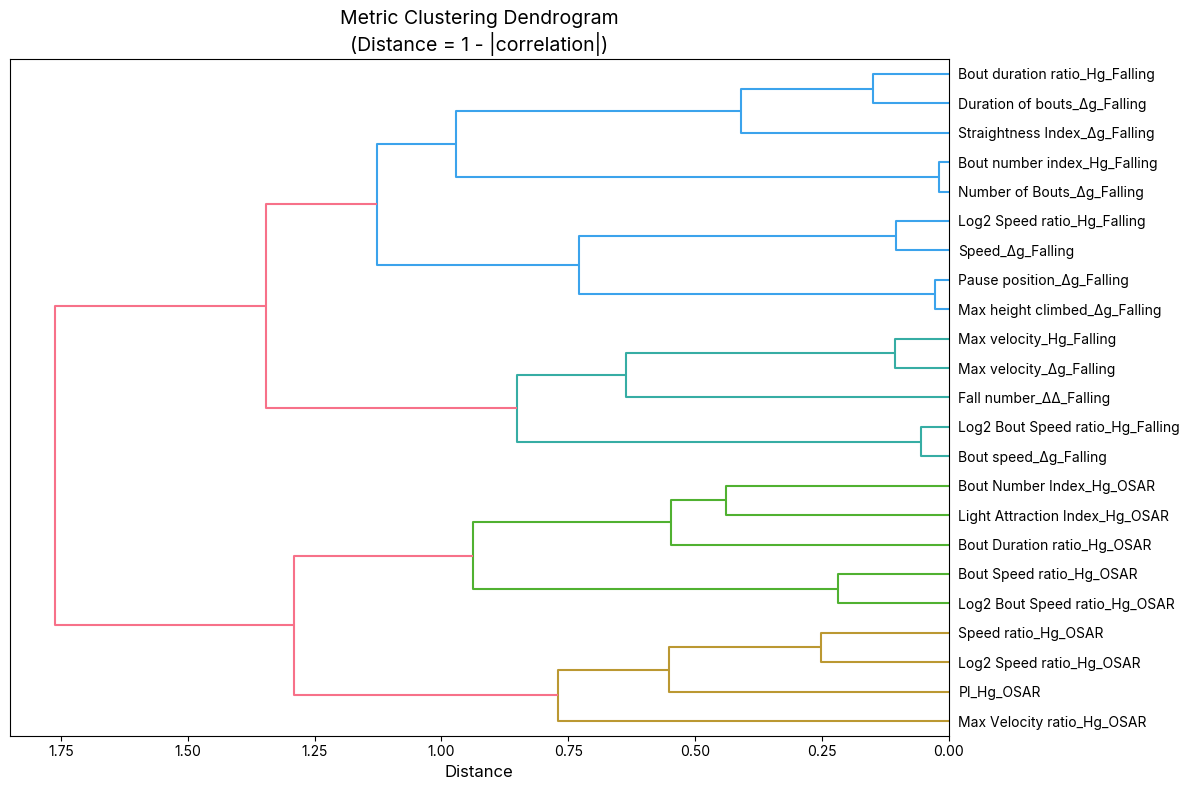

Dendrogram saved as 'metric_clustering_dendrogram.png'


In [22]:
# Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram = hierarchy.dendrogram(
    linkage_matrix,
    labels=list(corr_matrix.columns),
    orientation='left',
    leaf_font_size=10
)
plt.title('Metric Clustering Dendrogram\n(Distance = 1 - |correlation|)', fontsize=14)
plt.xlabel('Distance', fontsize=12)
plt.tight_layout()
plt.show()

# # Save the plot
# plt.savefig('metric_clustering_dendrogram.png', dpi=300, bbox_inches='tight')
print("Dendrogram saved as 'metric_clustering_dendrogram.png'")

<Figure size 1400x1200 with 0 Axes>

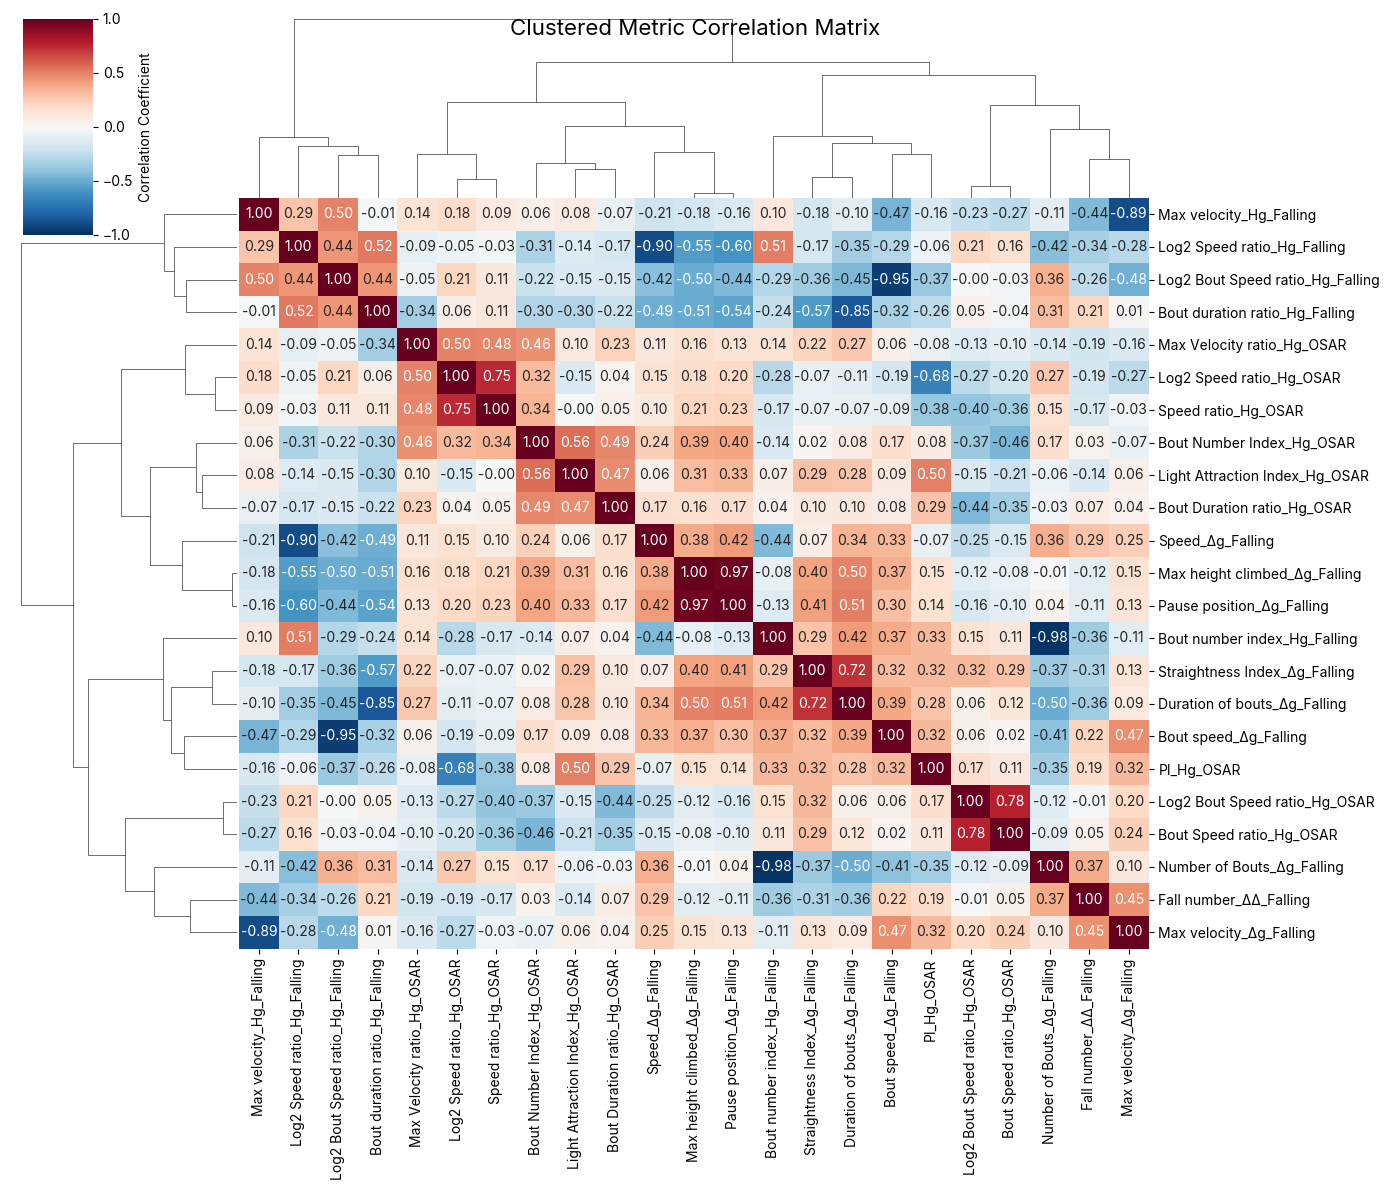

Correlation heatmap saved as 'metric_correlation_heatmap.png'


In [23]:
# Plot clustered correlation heatmap
plt.figure(figsize=(14, 12))

# Create clustermap
clustermap = sns.clustermap(
    corr_matrix,
    method='ward',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Correlation Coefficient'},
    figsize=(14, 12)
)

clustermap.fig.suptitle('Clustered Metric Correlation Matrix', y=0.98, fontsize=16)
plt.show()

# Save the plot
# clustermap.savefig('metric_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("Correlation heatmap saved as 'metric_correlation_heatmap.png'")

## 5. Identify Metric Clusters

Group metrics into clusters based on similarity.

In [24]:
# Set distance threshold for forming clusters
cluster_threshold = 0.3  # Adjust this value (0.2-0.5 typical range)

# Get cluster assignments
cluster_assignments = hierarchy.fcluster(linkage_matrix, cluster_threshold, criterion='distance')

# Group metrics by cluster
clusters = {}
for i, metric in enumerate(corr_matrix.columns):
    cluster_id = cluster_assignments[i]
    if cluster_id not in clusters:
        clusters[cluster_id] = []
    clusters[cluster_id].append(metric)

print(f"Found {len(clusters)} clusters at distance threshold {cluster_threshold}:")
print("="*60)

for cluster_id, metrics in clusters.items():
    print(f"\nCluster {cluster_id} ({len(metrics)} metrics):")
    for metric in metrics:
        print(f"  • {metric}")
    
    # Show correlations within cluster if more than 1 metric
    if len(metrics) > 1:
        cluster_corr = corr_matrix.loc[metrics, metrics]
        avg_corr = cluster_corr.values[np.triu_indices_from(cluster_corr.values, k=1)].mean()
        print(f"    Average within-cluster correlation: {avg_corr:.3f}")

Found 15 clusters at distance threshold 0.3:

Cluster 10 (1 metrics):
  • Fall number_ΔΔ_Climbing

Cluster 12 (2 metrics):
  • Speed_Δg_Climbing
  • Log2 Speed ratio_Hg_Climbing
    Average within-cluster correlation: -0.897

Cluster 11 (2 metrics):
  • Max height climbed_Δg_Climbing
  • Pause position_Δg_Climbing
    Average within-cluster correlation: 0.974

Cluster 8 (2 metrics):
  • Bout speed_Δg_Climbing
  • Log2 Bout Speed ratio_Hg_Climbing
    Average within-cluster correlation: -0.946

Cluster 9 (2 metrics):
  • Max velocity_Δg_Climbing
  • Max velocity_Hg_Climbing
    Average within-cluster correlation: -0.895

Cluster 15 (1 metrics):
  • Straightness Index_Δg_Climbing

Cluster 14 (2 metrics):
  • Duration of bouts_Δg_Climbing
  • Bout duration ratio_Hg_Climbing
    Average within-cluster correlation: -0.851

Cluster 13 (2 metrics):
  • Number of Bouts_Δg_Climbing
  • Bout number index_Hg_Climbing
    Average within-cluster correlation: -0.981

Cluster 2 (1 metrics):
  • PI_Hg

## 6. Select Representative Metrics

Choose one representative metric from each cluster based on:
1. Highest variance (captures most information)
2. Least missing data  
3. Highest average correlation with cluster members

In [25]:
representatives = []
cluster_info = []

for cluster_id, metrics in clusters.items():
    if len(metrics) == 1:
        # Single metric cluster
        representatives.append(metrics[0])
        cluster_info.append({
            'cluster_id': cluster_id,
            'cluster_size': 1,
            'metrics': '; '.join(metrics),
            'representative': metrics[0],
            'selection_reason': 'Single metric'
        })
    else:
        # Multi-metric cluster - select best representative
        cluster_metrics = metric_data[metrics]
        
        # Calculate selection criteria for each metric
        scores = {}
        for metric in metrics:
            # 1. Variance (normalized)
            variance_score = cluster_metrics[metric].var()
            
            # 2. Missing data penalty (lower is better)
            missing_penalty = cluster_metrics[metric].isnull().sum() / len(cluster_metrics)
            
            # 3. Average correlation with other cluster members
            other_metrics = [m for m in metrics if m != metric]
            if other_metrics:
                avg_corr = np.abs(corr_matrix.loc[metric, other_metrics]).mean()
            else:
                avg_corr = 0
            
            # Combined score (higher is better)
            scores[metric] = variance_score * (1 - missing_penalty) * (1 + avg_corr)
        
        # Select metric with highest score
        best_metric = max(scores.keys(), key=lambda x: scores[x])
        representatives.append(best_metric)
        
        cluster_info.append({
            'cluster_id': cluster_id,
            'cluster_size': len(metrics),
            'metrics': '; '.join(metrics),
            'representative': best_metric,
            'selection_reason': f'Score: {scores[best_metric]:.3f}'
        })

# Create summary DataFrame
cluster_summary = pd.DataFrame(cluster_info)
print("Cluster Summary:")
print(cluster_summary.to_string(index=False))

print(f"\n{'='*60}")
print(f"SELECTED {len(representatives)} REPRESENTATIVE METRICS:")
print(f"{'='*60}")
for i, rep in enumerate(representatives, 1):
    cluster_size = cluster_summary[cluster_summary['representative'] == rep]['cluster_size'].iloc[0]
    print(f"{i:2d}. {rep} (represents {cluster_size} metric{'s' if cluster_size > 1 else ''})")

Cluster Summary:
 cluster_id  cluster_size                                                      metrics                 representative selection_reason
         10             1                                       Fall number_ΔΔ_Climbing         Fall number_ΔΔ_Climbing    Single metric
         12             2                Speed_Δg_Climbing; Log2 Speed ratio_Hg_Climbing    Log2 Speed ratio_Hg_Climbing     Score: 0.626
         11             2     Max height climbed_Δg_Climbing; Pause position_Δg_Climbing      Pause position_Δg_Climbing     Score: 0.731
          8             2      Bout speed_Δg_Climbing; Log2 Bout Speed ratio_Hg_Climbing          Bout speed_Δg_Climbing     Score: 0.478
          9             2             Max velocity_Δg_Climbing; Max velocity_Hg_Climbing        Max velocity_Δg_Climbing     Score: 0.276
         15             1                                Straightness Index_Δg_Climbing  Straightness Index_Δg_Climbing    Single metric
         14           

## 7. High Correlation Analysis

Identify pairs of metrics with very high correlations.

In [26]:
# Find high correlation pairs
correlation_threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > correlation_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

if high_corr_pairs:
    print(f"High Correlation Pairs (|r| > {correlation_threshold}):")
    print("="*50)
    for metric1, metric2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{metric1} ↔ {metric2}: r = {corr_val:.3f}")
else:
    print(f"No metric pairs found with |correlation| > {correlation_threshold}")

High Correlation Pairs (|r| > 0.8):
Number of Bouts_Δg_Climbing ↔ Bout number index_Hg_Climbing: r = -0.981
Max height climbed_Δg_Climbing ↔ Pause position_Δg_Climbing: r = 0.974
Bout speed_Δg_Climbing ↔ Log2 Bout Speed ratio_Hg_Climbing: r = -0.946
Speed_Δg_Climbing ↔ Log2 Speed ratio_Hg_Climbing: r = -0.897
Max velocity_Δg_Climbing ↔ Max velocity_Hg_Climbing: r = -0.895
Duration of bouts_Δg_Climbing ↔ Bout duration ratio_Hg_Climbing: r = -0.851


## 8. Create Reduced Dataset

Create a new dataset with only the representative metrics for subsequent MBON analysis.

In [ ]:
# Create reduced dataset with representative metrics only
reduced_data = metric_data[representatives].copy()

# Add back metadata if available
if not metadata_filtered.empty:
    reduced_data = pd.concat([metadata_filtered, reduced_data], axis=1)

print(f"Reduced dataset shape: {reduced_data.shape}")
print(f"Original dataset: {metric_data.shape[0]} MBONs × {metric_data.shape[1]} metrics")
print(f"Reduced dataset: {reduced_data.shape[0]} MBONs × {len(representatives)} metrics")
print(f"Dimensionality reduction: {len(representatives)/metric_data.shape[1]*100:.1f}% of original metrics")

print(f"\nReduced dataset columns:")
print(list(reduced_data.columns))

In [ ]:
# Save results
save_results = True  # Set to True to save files

if save_results:
    # Save reduced dataset
    reduced_data.to_csv('reduced_metrics_dataset.csv')
    print("✓ Reduced dataset saved as 'reduced_metrics_dataset.csv'")
    
    # Save cluster information
    cluster_summary.to_csv('metric_cluster_info.csv', index=False)
    print("✓ Cluster information saved as 'metric_cluster_info.csv'")
    
    # Save correlation matrix
    corr_matrix.to_csv('metric_correlation_matrix.csv')
    print("✓ Correlation matrix saved as 'metric_correlation_matrix.csv'")
    
    # Save representative metrics list
    pd.DataFrame({'representative_metrics': representatives}).to_csv('representative_metrics_list.csv', index=False)
    print("✓ Representative metrics list saved as 'representative_metrics_list.csv'")
else:
    print("Set save_results = True to save output files")

## 9. Analysis Summary

Summary of the metric redundancy analysis results.

In [ ]:
print("═" * 60)
print("           METRIC REDUNDANCY ANALYSIS SUMMARY")
print("═" * 60)

print(f"Dataset: {metric_data.shape[0]} MBONs × {metric_data.shape[1]} metrics")
print(f"Correlation method: {correlation_method}")
print(f"Clustering method: {linkage_method} linkage")
print(f"Cluster threshold: {cluster_threshold}")

print(f"\nResults:")
print(f"• Found {len(clusters)} metric clusters")
print(f"• Selected {len(representatives)} representative metrics")
print(f"• Achieved {(1 - len(representatives)/metric_data.shape[1])*100:.1f}% dimensionality reduction")
print(f"• {len(high_corr_pairs)} metric pairs with |correlation| > {correlation_threshold}")

print(f"\nNext steps:")
print(f"• Use the reduced dataset for MBON clustering analysis")
print(f"• This solves the p > n problem (now {len(representatives)} metrics for {metric_data.shape[0]} MBONs)")
print(f"• Reduced dataset captures the main behavioral dimensions without redundancy")

print(f"\nFiles created:")
if save_results:
    print(f"• reduced_metrics_dataset.csv - Dataset for MBON analysis")
    print(f"• metric_cluster_info.csv - Detailed cluster information")
    print(f"• metric_correlation_matrix.csv - Full correlation matrix")
    print(f"• representative_metrics_list.csv - List of selected metrics")
    print(f"• metric_clustering_dendrogram.png - Clustering visualization")
    print(f"• metric_correlation_heatmap.png - Correlation heatmap")
else:
    print(f"• Set save_results = True to create output files")

print("═" * 60)